# Proyección del Presupuesto de la Federación de México (2026–2030)

### Metodología: Regresión Lineal sobre Tasas de Crecimiento Anual

Dado que el presupuesto crece de forma no lineal (refleja inflación, expansión fiscal y ciclos económicos), se optó por una metodología simple y robusta en dos pasos:

1. **Cálculo de tasas de crecimiento anual (YoY):** Se calcula el crecimiento porcentual año a año del gasto total, capturando la dinámica estructural de la serie.
2. **Regresión lineal sobre las tasas:** Se ajusta una regresión lineal simple (OLS) sobre el tiempo para modelar la tendencia subyacente de las tasas de crecimiento y proyectar los años 2026–2030.
3. **Intervalos de confianza:** Se construyen bandas al ±1 desviación estándar de los residuales de la regresión, para cuantificar la incertidumbre en la proyección.

> **Nota:** Las cifras de 2026 son preliminares según la SHCP. La proyección asume continuidad de tendencias históricas y no incorpora shocks exógenos (reformas fiscales, crisis, etc.).

---

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from lxml import etree
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Lectura del archivo SpreadsheetML
with open(r'C:\Users\rolg0\Downloads\Pensiones\EstadisticasOportunas.xls', 'rb') as f:
    content = f.read()

parser = etree.XMLParser(recover=True)
root   = etree.fromstring(content, parser)
ns     = 'urn:schemas-microsoft-com:office:spreadsheet'

sheet  = root.findall(f'.//{{{ns}}}Worksheet')[0]
table  = sheet.find(f'{{{ns}}}Table')
rows   = table.findall(f'{{{ns}}}Row')

# Años: 36 columnas -> 1990-2025
years = list(range(1990, 2026))
def parse_row(row_xml):
    cells = row_xml.findall(f'{{{ns}}}Cell')
    vals  = []
    for c in cells:
        d = c.find(f'{{{ns}}}Data')
        vals.append(d.text if d is not None else '')
    return vals

total_vals = parse_row(rows[3])[1:]         
gasto_total = [float(v)/1e6 for v in total_vals]  # convertir a billones MXN

df = pd.DataFrame({'año': years, 'gasto_total_bn': gasto_total})
df.head()

,año,gasto_total_bn
0,1990,204.215324
1,1991,227.933150
2,1992,249.287323
3,1993,282.066411
4,1994,326.250680


In [3]:
#Tasas de Crecimiento Anual 
df['tasa_crec'] = df['gasto_total_bn'].pct_change() * 100
df_crec = df.dropna().copy()   # primera fila no tiene tasa

print("Estadísticas de la tasa de crecimiento anual:")
print(df_crec['tasa_crec'].describe().round(2))

Estadísticas de la tasa de crecimiento anual:
count    35.00
mean     11.89
std       8.04
min      -3.09
25%       7.89
50%       9.37
75%      13.02
max      38.12
Name: tasa_crec, dtype: float64


In [4]:
# Regresión Lineal sobre las tasas
X = df_crec['año'].values
y = df_crec['tasa_crec'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Residuales (desviación estándar para bandas)
y_hat = slope * X + intercept
residuals = y - y_hat
sigma = np.std(residuals)

print(f"Pendiente   : {slope:.4f}")
print(f"Intercepto  : {intercept:.4f}")
print(f"Sigma res.  : {sigma:.4f}")

Pendiente   : -0.4264
Intercepto  : 868.0758
Sigma res.  : 6.6483


In [5]:
# Proyección 2026-2030
años_proy = np.array([2026, 2027, 2028, 2029, 2030])
tasa_proy_central = slope * años_proy + intercept
tasa_proy_alta    = tasa_proy_central + sigma
tasa_proy_baja    = tasa_proy_central - sigma

# Gasto proyectado a partir del último dato real (2025)
gasto_base = df.loc[df['año'] == 2025, 'gasto_total_bn'].values[0]

gasto_proy_central = [gasto_base]
gasto_proy_alta    = [gasto_base]
gasto_proy_baja    = [gasto_base]

for i in range(len(años_proy)):
    gasto_proy_central.append(gasto_proy_central[-1] * (1 + tasa_proy_central[i]/100))
    gasto_proy_alta.append(gasto_proy_alta[-1]       * (1 + tasa_proy_alta[i]/100))
    gasto_proy_baja.append(gasto_proy_baja[-1]       * (1 + tasa_proy_baja[i]/100))

# Quitar el punto base (2025)
gasto_proy_central = gasto_proy_central[1:]
gasto_proy_alta    = gasto_proy_alta[1:]
gasto_proy_baja    = gasto_proy_baja[1:]

df_proy = pd.DataFrame({
    'año'    : años_proy,
    'central': gasto_proy_central,
    'alta'   : gasto_proy_alta,
    'baja'   : gasto_proy_baja
})

print("\nProyección del Gasto Total (billones MXN):")
print(df_proy.round(2).to_string(index=False))


Proyección del Gasto Total (billones MXN):
 año  central     alta    baja
2026  9998.79 10636.64 9360.93
2027 10377.73 11746.91 9093.36
2028 10726.78 12922.98 8794.66
2029 11041.83 14161.69 8468.27
2030 11319.06 15458.75 8117.89


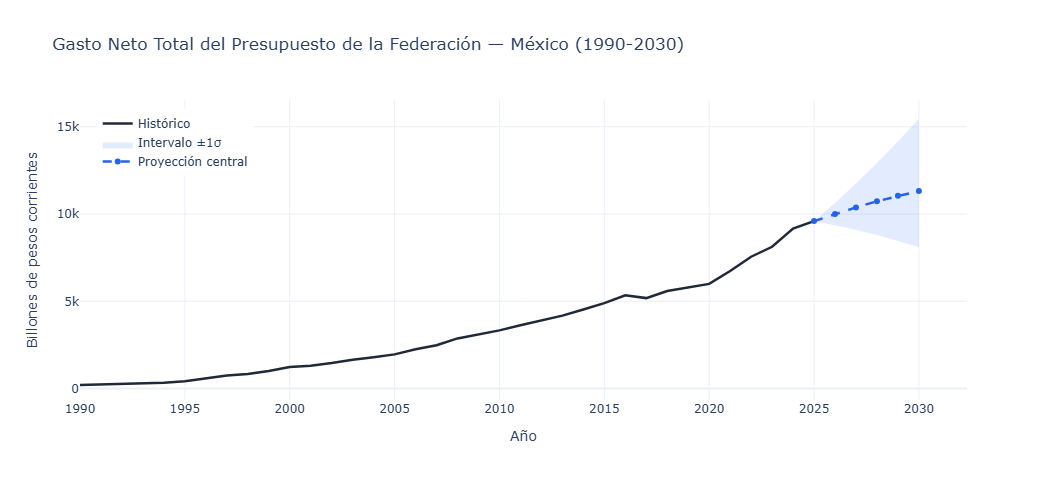

In [6]:
# Gráfico 1: Gasto Total Histórico + Proyección
fig = go.Figure()

fig.add_trace(go.Scatter(x=df['año'], y=df['gasto_total_bn'], name='Histórico', line=dict(color='#1f2937', width=2.5)))

fig.add_trace(go.Scatter(x=np.concatenate([[2025], años_proy, años_proy[::-1], [2025]]),
    y=np.concatenate([[gasto_base], gasto_proy_alta, gasto_proy_baja[::-1], [gasto_base]]),
    fill='toself', fillcolor='rgba(59,130,246,0.15)', line_color='rgba(0,0,0,0)', name='Intervalo ±1σ'))

fig.add_trace(go.Scatter(x=np.concatenate([[2025], años_proy]), y=np.concatenate([[gasto_base], gasto_proy_central]),
    name='Proyección central', line=dict(color='#2563eb', width=2.5, dash='dash')))

fig.update_layout(title='Gasto Neto Total del Presupuesto de la Federación — México (1990-2030)',
                  xaxis_title='Año', yaxis_title='Billones de pesos corrientes',
                  hovermode='x unified', template='plotly_white', height=480, width=980, legend=dict(x=0.02, y=0.97))
fig.show()

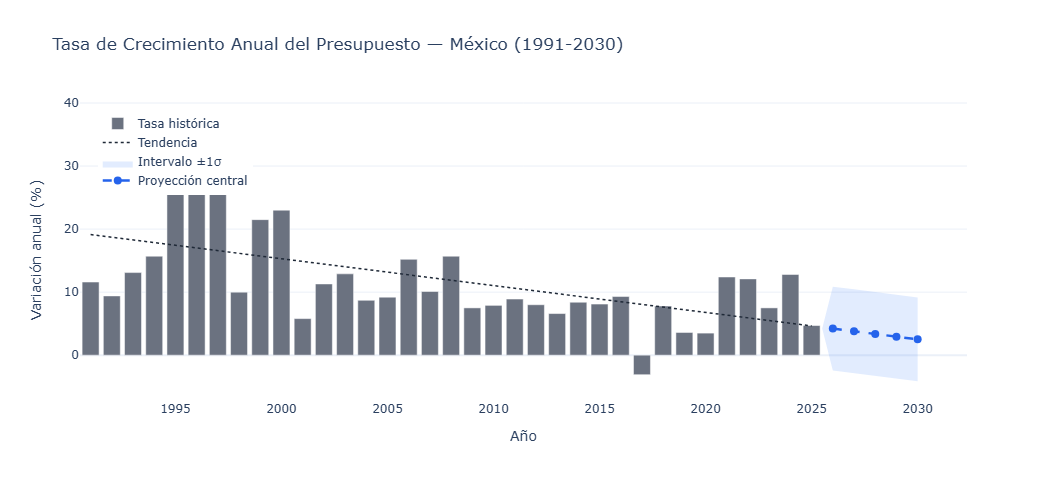

In [7]:
# Gráfico 2: Tasas de crecimiento históricas + proyección
fig2 = go.Figure()

fig2.add_trace(go.Bar(x=df_crec['año'], y=df_crec['tasa_crec'].round(1),name='Tasa histórica', marker_color='#6b7280'))

fig2.add_trace(go.Scatter(x=df_crec['año'], y=y_hat,name='Tendencia', line=dict(color='#1f2937', width=1.5, dash='dot')))

fig2.add_trace(go.Scatter(x=np.concatenate([[2025.5], años_proy, años_proy[::-1], [2025.5]]),
    y=np.concatenate([[tasa_proy_central[0]], tasa_proy_alta, tasa_proy_baja[::-1], [tasa_proy_central[0]]]),
    fill='toself', fillcolor='rgba(59,130,246,0.15)', line_color='rgba(0,0,0,0)', name='Intervalo ±1σ'))

fig2.add_trace(go.Scatter(x=años_proy, y=tasa_proy_central, name='Proyección central', mode='lines+markers',
                          line=dict(color='#2563eb', width=2.5, dash='dash'), marker=dict(size=8)))

fig2.update_layout(title='Tasa de Crecimiento Anual del Presupuesto — México (1991-2030)',
                   xaxis_title='Año', yaxis_title='Variación anual (%)', hovermode='x unified', template='plotly_white',
                   height=480, width=980, legend=dict(x=0.02, y=0.97))
fig2.show()

In [8]:
# Resumen
print("\n---- Proyección del Gasto Neto Total del Presupuesto de la Federación ---")
print(f"{'Año':<6} {'Escenario bajo':>16} {'Central':>12} {'Escenario alto':>16} {'Tasa central':>14}")
print('-' * 70)
for i, yr in enumerate(años_proy):
    print(f"{yr:<6} {gasto_proy_baja[i]:>14.2f} Bn  {gasto_proy_central[i]:>10.2f} Bn  "
          f"{gasto_proy_alta[i]:>14.2f} Bn  {tasa_proy_central[i]:>12.1f}%")
print('\nBn = Billones de pesos corrientes')


---- Proyección del Gasto Neto Total del Presupuesto de la Federación ---
Año      Escenario bajo      Central   Escenario alto   Tasa central
----------------------------------------------------------------------
2026          9360.93 Bn     9998.79 Bn        10636.64 Bn           4.2%
2027          9093.36 Bn    10377.73 Bn        11746.91 Bn           3.8%
2028          8794.66 Bn    10726.78 Bn        12922.98 Bn           3.4%
2029          8468.27 Bn    11041.83 Bn        14161.69 Bn           2.9%
2030          8117.89 Bn    11319.06 Bn        15458.75 Bn           2.5%

Bn = Billones de pesos corrientes


# Simulación y Proyección de Inflación en México (2026-2030)

Implementación del modelo estocástico de reversión a la media (Vasicek) para proyectar la inflación anual. Se utiliza calibración por mínimos cuadrados sobre datos históricos de la Secretaría de Hacienda y Crédito Público y simulaciones de Monte Carlo. 

In [9]:
import numpy as np; import pandas as pd; import plotly.graph_objects as go
from scipy.stats import norm; import warnings
warnings.filterwarnings("ignore")

In [10]:
# Procesamiento y Modelo
df = pd.read_excel(r"C:\Users\rolg0\Downloads\Consulta_20260319-194049545.xlsx", header=None, skiprows=18)
df.columns = ["fecha", "inflacion"]; df["inflacion"] = pd.to_numeric(df["inflacion"], errors="coerce")
df = df.dropna().reset_index(drop=True); X = df[df["fecha"] >= "2000-01-01"]["inflacion"].values; dt = 1/12

### Modelo de Vasicek

In [11]:
X_lag, X_next = X[:-1], X[1:]; b, a = np.polyfit(X_lag, X_next, 1)
theta, mu = -np.log(b)/dt, a/(1-b) #Reversión y velocidad de reversión a la media
sigma = np.std(X_next - (a + b * X_lag))/np.sqrt(dt) # Volatilidad

# Monte Carlo e implementación del modelo
n_sims, X0 = 100, X[-1]
rng = np.random.default_rng(87)
fechas_fut = pd.date_range(df["fecha"].iloc[-1] + pd.DateOffset(months=1), "2030-12-01", freq="MS")
n_pasos = len(fechas_fut); trayectorias = np.zeros((n_pasos + 1, n_sims)); trayectorias[0] = X0
exp_dt, var_dt = np.exp(-theta*dt), sigma**2 * (1-np.exp(-2*theta*dt))/(2*theta)


for t in range(n_pasos): trayectorias[t+1] = mu + (trayectorias[t]-mu)*exp_dt + np.sqrt(var_dt)*rng.standard_normal(n_sims)
sims = trayectorias[1:]; p = {n: np.percentile(sims, n, axis=1) for n in [10, 25, 50, 75, 90]}

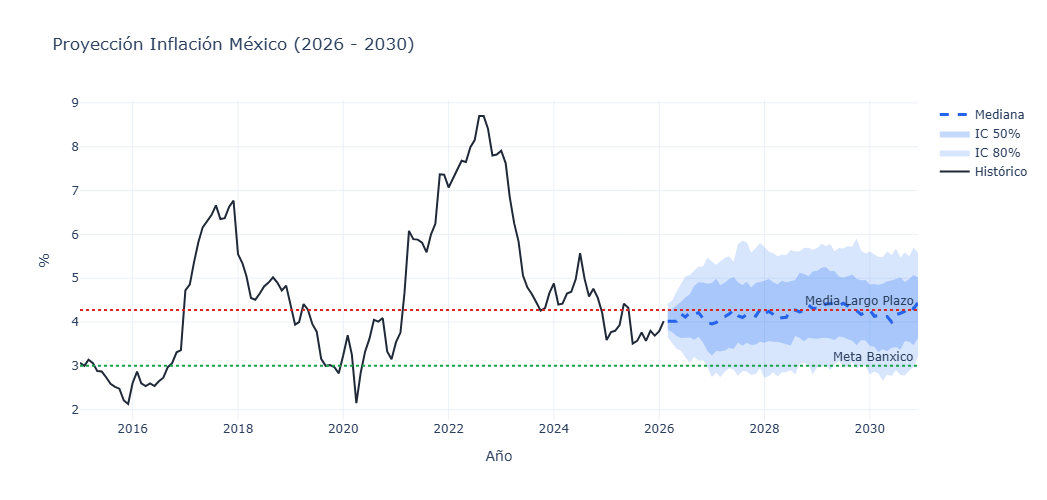

In [12]:
# Gráficos
fig = go.Figure()
hist = df[df["fecha"] >= "2015-01-01"]
fig.add_trace(go.Scatter(x=hist["fecha"], y=hist["inflacion"], name="Histórico", line=dict(color="#1f2937", width=2)))

# Áreas de Incertidumbre
fig.add_trace(go.Scatter(x=fechas_fut, y=p[90], fill=None, mode='lines', line_color='rgba(59,130,246,0)', showlegend=False))
fig.add_trace(go.Scatter(x=fechas_fut, y=p[10], fill='tonexty', fillcolor='rgba(59,130,246,0.2)', name='IC 80%', line_color='rgba(0,0,0,0)'))
fig.add_trace(go.Scatter(x=fechas_fut, y=p[75], fill=None, mode='lines', line_color='rgba(59,130,246,0)', showlegend=False))
fig.add_trace(go.Scatter(x=fechas_fut, y=p[25], fill='tonexty', fillcolor='rgba(59,130,246,0.3)', name='IC 50%', line_color='rgba(0,0,0,0)'))

# Líneas de Proyección y Meta de Banxico
fig.add_trace(go.Scatter(x=fechas_fut, y=p[50], name="Mediana", line=dict(color="#2563eb", width=3, dash='dash')))
fig.add_hline(y=3.0, line_dash="dot", line_color="#16a34a", annotation_text="Meta Banxico")
fig.add_hline(y=mu, line_dash="dot", line_color="#dc2626", annotation_text="Media Largo Plazo")

fig.update_layout(height=500, width=1000,
    title="Proyección Inflación México (2026 - 2030)", 
    hovermode="x unified", 
    template="plotly_white", 
    xaxis_title="Año", 
    yaxis_title="%")
fig.show()

In [13]:
# Proyecciones en cuantiles
print(f"\n{'Año':<6} {'p10':>7} {'p50':>7} {'p90':>7}\n" + "-"*30)
for anio in range(2026, 2031):
    m = fechas_fut == pd.Timestamp(f"{anio}-12-01")
    if m.any():
        idx = np.where(m)[0][0]
        print(f"{anio:<6} {p[10][idx]:>7.2f} {p[50][idx]:>7.2f} {p[90][idx]:>7.2f}")


Año        p10     p50     p90
------------------------------
2026      2.98    3.99    5.47
2027      2.94    4.28    5.80
2028      2.80    4.31    5.65
2029      3.01    4.22    5.56
2030      3.22    4.44    5.58
